# Projeto Integrador - Exploração e Tratamento Inicial

Este notebook serve como o primeiro passo para o projeto. Aqui vamos fazer a ingestão exploratória das 3 fontes (BCB, IBGE e SIM/SUS), além da limpeza básica dos dados (remoção de nulos, tipagem e deduplicação) e algumas visualizações iniciais.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

# Configurações visuais do seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Banco Central (BCB) - Inadimplência
Vamos buscar a série histórica de inadimplência de operações de crédito (Série SGS 21082).

In [2]:
# --- INGESTÃO ---
url_bcb = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.21082/dados?formato=json&dataInicial=01/01/2019'
resp_bcb = requests.get(url_bcb)
df_bcb = pd.DataFrame(resp_bcb.json())

# --- TRATAMENTO (Limpeza e Tipagem) ---
df_bcb['data'] = pd.to_datetime(df_bcb['data'], format='%d/%m/%Y')
df_bcb['valor'] = pd.to_numeric(df_bcb['valor'], errors='coerce')

# Remoção de nulos e duplicatas
df_bcb = df_bcb.dropna(subset=['valor'])
df_bcb = df_bcb.drop_duplicates(subset=['data'])
df_bcb = df_bcb.sort_values('data')

print("Registros BCB:", len(df_bcb))
df_bcb.head()

Registros BCB: 91


,data,valor
0,2019-01-01,3.01
1,2019-02-01,2.96
2,2019-03-01,3.04
3,2019-04-01,3.07
4,2019-05-01,3.10


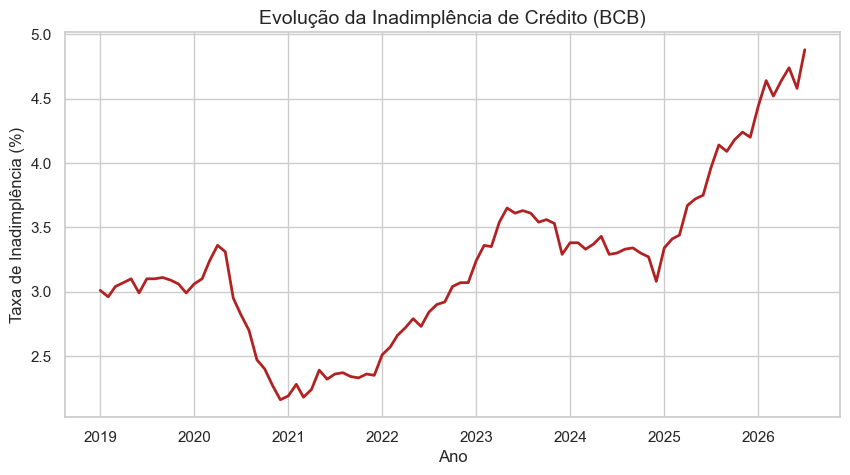

In [3]:
# --- PLOT BCB ---
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_bcb, x='data', y='valor', color='firebrick', linewidth=2)
plt.title('Evolução da Inadimplência de Crédito (BCB)', fontsize=14)
plt.ylabel('Taxa de Inadimplência (%)')
plt.xlabel('Ano')
plt.show()

## 2. IBGE - População dos Estados
Vamos puxar dados populacionais dos Estados via API de agregados do IBGE (SIDRA).

In [12]:
url_sidra = "https://apisidra.ibge.gov.br/values/t/6579/v/9324/p/2021/n3/all"

resp_ibge = requests.get(url_sidra)
resp_ibge.raise_for_status()

dados_ibge = resp_ibge.json()

# Ignora o cabeçalho descritivo (posição 0)
df_raw = pd.DataFrame(dados_ibge[1:])

# Mapeamento com as colunas corretas descobertas no cabeçalho
df_pop = pd.DataFrame(
    {
        "uf": df_raw["D3N"],  # Nome do Estado (ex: São Paulo, Pará)
        "codigo_uf": df_raw["D3C"],  # Código IBGE do Estado (ex: 35, 15)
        "populacao": df_raw["V"],  # Valor da população
    }
)

# --- TRATAMENTO ---
df_pop["populacao"] = pd.to_numeric(df_pop["populacao"], errors="coerce")
df_pop = df_pop.dropna(subset=["populacao"]).sort_values(
    "populacao", ascending=False
)

print("Registros IBGE:", len(df_pop))
print(df_pop.head())

Registros IBGE: 27
                uf codigo_uf  populacao
19       São Paulo        35   46649132
16    Minas Gerais        31   21411923
18  Rio de Janeiro        33   17463349
15           Bahia        29   14985284
20          Paraná        41   11597484


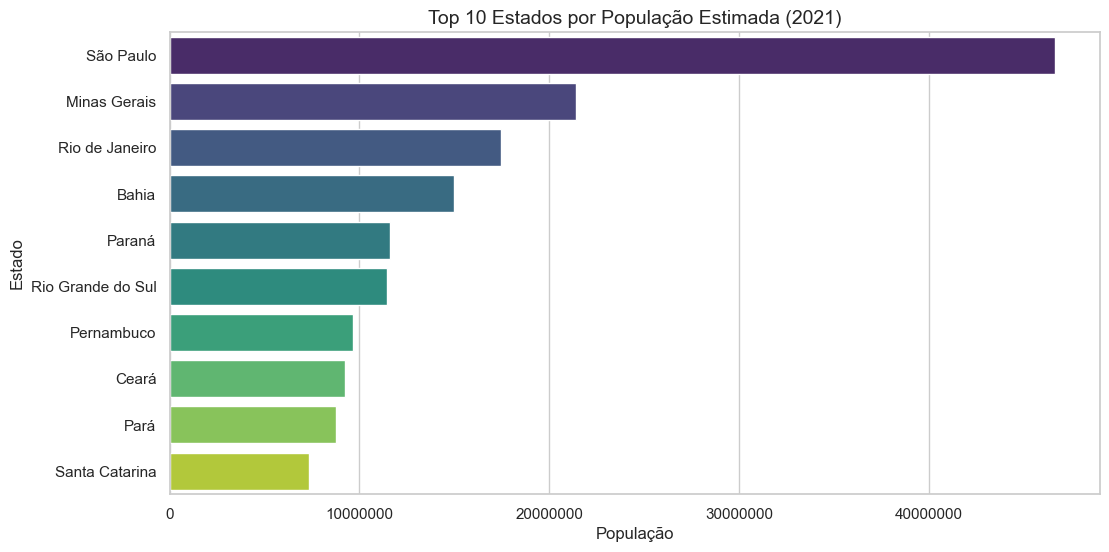

In [14]:
# --- PLOT IBGE ---
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_pop.head(10),
    x="populacao",
    y="uf",
    hue="uf",
    palette="viridis",
    legend=False,
)

plt.title("Top 10 Estados por População Estimada (2021)", fontsize=14)
plt.xlabel("População")
plt.ylabel("Estado")

# Formata o eixo X para exibir os valores de população de forma legível
plt.ticklabel_format(style="plain", axis="x")

plt.show()